# 02 · Feature interactions on the Iris QNN

**Computes.** The six order-2 pairwise **Shapley interaction indices** (Grabisch--Roubens) of the same single-$R_Y$ Iris QNN ($d=4$), from the *same* exact multilinear extension, by Owen diagonal integration of the second mixed partial versus exact $2^4$ enumeration. The interaction-exactness threshold is $M\ge\lceil(d-1)/2\rceil=2$ (one lower per extra order than first-order, per Prop. *Interaction exactness*): $M=2$ is exact, $M=1$ is not.

**Produces.** `figures/fig_feature_int.png`; and the composite **panel (a)** of the paper figure, `figures/fig_feature.png` (first-order + interactions), plus `results/02.json`.

**Seed.** Fixed: QNN seed 0, instance cohort seed 123.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

SEED = 0
np.random.seed(SEED)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9})
D = 4
pairs = list(combinations(range(D), 2))
M_INT = T.threshold_M(D, order=2)          # ceil((d-1)/2) = 2
print(f"d={D}; {len(pairs)} pairs; interaction exactness threshold M = {M_INT}")

d=4; 6 pairs; interaction exactness threshold M = 2


In [2]:
X, y, baseline, qnn, acc = datasets.iris_qnn(D)
cohort = datasets.pick_instances(X, 8, seed=123)
print(f"Iris d={D}: train acc = {acc:.3f}; cohort = {len(cohort)} instances")

Iris d=4: train acc = 0.970; cohort = 8 instances


In [3]:
# Exact GR interactions vs Owen (M=2 exact, M=1 inexact) over the cohort
iu = np.triu_indices(D, 1)
I_exact, I_M2, I_M1 = [], [], []
phi_exact, phi_M2 = [], []                  # first-order too, for the composite panel
for idx, x in cohort:
    tab = exact.feature_value_table(qnn, D, x, baseline)
    I_exact.append(exact.exact_interactions(tab, D))
    I_M2.append(owen.owen_integral_interactions(qnn, D, x, baseline, M_INT)[0])
    I_M1.append(owen.owen_integral_interactions(qnn, D, x, baseline, 1)[0])
    phi_exact.append(exact.exact_shapley(tab, D))
    phi_M2.append(owen.owen_integral_shapley(qnn, D, x, baseline, M_INT)[0])
I_exact = np.array(I_exact); I_M2 = np.array(I_M2); I_M1 = np.array(I_M1)
phi_exact = np.array(phi_exact); phi_M2 = np.array(phi_M2)

ev_pair = owen.owen_integral_interactions(qnn, D, cohort[0][1], baseline, M_INT)[1]
flat = lambda A: np.array([a[iu] for a in A])
mae_I2 = metrics.mae(flat(I_M2), flat(I_exact))
mae_I1 = metrics.mae(flat(I_M1), flat(I_exact))
print(f"Owen M={M_INT} interactions: MAE = {mae_I2:.2e}   evals/pair = {ev_pair}")
print(f"Owen M=1 interactions:       MAE = {mae_I1:.2e}  (inexact)")

Owen M=2 interactions: MAE = 9.51e-17   evals/pair = 8
Owen M=1 interactions:       MAE = 2.62e-06  (inexact)


In [4]:
# Dominant pairwise coupling (hero instance)
hero = 0
Ih = I_exact[hero]
dom = max(pairs, key=lambda p: abs(Ih[p]))
print(f"hero instance {cohort[hero][0]}: pairwise interaction indices")
for p in pairs:
    star = "  <-- dominant" if p == dom else ""
    print(f"  features {p}: exact {Ih[p]:+.6f}   Owen {I_M2[hero][p]:+.6f}{star}")
print(f"dominant pair = {dom}  (|I| = {abs(Ih[dom]):.4f}); additive Shapley misses this coupling")

hero instance 1: pairwise interaction indices
  features (0, 1): exact -0.000667   Owen -0.000667
  features (0, 2): exact +0.070988   Owen +0.070988
  features (0, 3): exact +0.001315   Owen +0.001315
  features (1, 2): exact +0.005278   Owen +0.005278
  features (1, 3): exact -0.000001   Owen -0.000001
  features (2, 3): exact +0.118715   Owen +0.118715  <-- dominant
dominant pair = (2, 3)  (|I| = 0.1187); additive Shapley misses this coupling


In [5]:
# Threshold sweep for the order-2 index
Ms = [1, 2, 3]
mae_by_M = np.array([
    metrics.mae(flat([owen.owen_integral_interactions(qnn, D, x, baseline, M)[0] for _, x in cohort]),
                flat(I_exact))
    for M in Ms])
for M, e in zip(Ms, mae_by_M):
    print(f"  M={M}: interaction MAE = {e:.2e}")

  M=1: interaction MAE = 2.62e-06
  M=2: interaction MAE = 9.51e-17
  M=3: interaction MAE = 8.35e-17


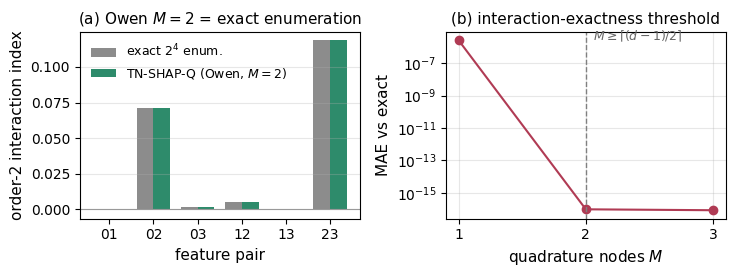

saved figures/fig_feature_int.png


In [6]:
# Figure fig_feature_int.png : (a) 6 pairwise indices exact vs Owen; (b) threshold
lab = [f"{i}{j}" for (i, j) in pairs]
ie = np.array([Ih[p] for p in pairs]); io = np.array([I_M2[hero][p] for p in pairs])
fig, (b1, b2) = plt.subplots(1, 2, figsize=(7.4, 2.9))
xb = np.arange(len(pairs)); wid = 0.38
b1.bar(xb - wid/2, ie, wid, color='0.55', label=r'exact $2^4$ enum.')
b1.bar(xb + wid/2, io, wid, color='#2e8b6b', label=r'TN-SHAP-Q (Owen, $M{=}2$)')
b1.axhline(0, color='0.6', lw=0.8); b1.set_xticks(xb); b1.set_xticklabels(lab)
b1.set_xlabel('feature pair'); b1.set_ylabel('order-2 interaction index')
b1.set_title('(a) Owen $M{=}2$ = exact enumeration')
b1.legend(frameon=False); b1.grid(alpha=0.3, axis='y')

b2.semilogy(Ms, np.clip(mae_by_M, 1e-18, None), 'o-', color='#b03b54')
b2.axvline(M_INT, color='0.5', ls='--', lw=1)
b2.text(M_INT + 0.06, mae_by_M[0], r'$M\geq\lceil(d-1)/2\rceil$', color='0.4', fontsize=9)
b2.set_xticks(Ms); b2.set_xlabel('quadrature nodes $M$')
b2.set_ylabel('MAE vs exact'); b2.set_title('(b) interaction-exactness threshold')
b2.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_feature_int.png')
plt.show()
print("saved figures/fig_feature_int.png")

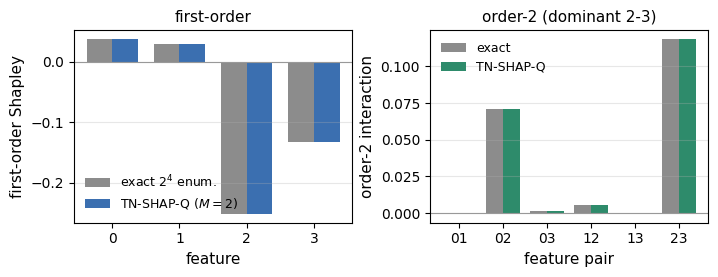

saved figures/fig_feature.png (paper panel a)


In [7]:
# Composite fig_feature.png = paper panel (a): first-order | order-2, exact vs Owen (hero)
fig, (c1, c2) = plt.subplots(1, 2, figsize=(7.4, 2.9))
xf = np.arange(D); wf = 0.38
c1.bar(xf - wf/2, phi_exact[hero], wf, color='0.55', label=r'exact $2^4$ enum.')
c1.bar(xf + wf/2, phi_M2[hero], wf, color='#3b6fb0', label=r'TN-SHAP-Q ($M{=}2$)')
c1.axhline(0, color='0.6', lw=0.8); c1.set_xticks(xf)
c1.set_xlabel('feature'); c1.set_ylabel('first-order Shapley')
c1.set_title('first-order'); c1.legend(frameon=False); c1.grid(alpha=0.3, axis='y')

c2.bar(xb - wid/2, ie, wid, color='0.55', label=r'exact')
c2.bar(xb + wid/2, io, wid, color='#2e8b6b', label=r'TN-SHAP-Q')
c2.axhline(0, color='0.6', lw=0.8); c2.set_xticks(xb); c2.set_xticklabels(lab)
c2.set_xlabel('feature pair'); c2.set_ylabel('order-2 interaction')
c2.set_title(f'order-2 (dominant {dom[0]}-{dom[1]})')
c2.legend(frameon=False); c2.grid(alpha=0.3, axis='y')
fig.tight_layout()
savefig(fig, 'fig_feature.png')
plt.show()
print("saved figures/fig_feature.png (paper panel a)")

In [8]:
# Headline JSON
res = {
    "task": "feature order-2 interactions (Iris d=4)",
    "d": D, "n_pairs": len(pairs), "M": int(M_INT), "threshold_M": int(M_INT),
    "evals_per_pair": int(ev_pair), "enum_evals": int(2**D),
    "mae": mae_I2, "mae_M1": mae_I1,
    "mae_by_M": {str(M): float(v) for M, v in zip(Ms, mae_by_M)},
    "dominant_pair": list(dom), "dominant_value": float(Ih[dom]),
    "threshold_ok": bool(mae_I2 < 1e-10 and mae_I1 > 1e-7),
}
save_results("02", res)
print("saved results/02.json")

saved results/02.json


In [9]:
# Verification: Owen M=2 reproduces GR enumeration to machine precision; M=1 does not
np.testing.assert_allclose(flat(I_M2), flat(I_exact), atol=1e-10, rtol=0)
assert mae_I1 > 1e-7, "M=1 must be inexact for order-2 below the threshold"
print(f"PASS  Owen M={M_INT} reproduces all {len(pairs)} GR interactions: MAE={mae_I2:.2e}, "
      f"{ev_pair} evals/pair vs {2**D} enumeration.")
print(f"      dominant pair {dom} (I={Ih[dom]:+.4f}); M=1 inexact (MAE={mae_I1:.2e}).")

PASS  Owen M=2 reproduces all 6 GR interactions: MAE=9.51e-17, 8 evals/pair vs 16 enumeration.
      dominant pair (2, 3) (I=+0.1187); M=1 inexact (MAE=2.62e-06).
